<a href="https://colab.research.google.com/github/naruephornminathy/Take-home-exam-submission/blob/main/Takehome_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###สร้างโครงสร้างไฟล์ในDrive




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install rasterio -q

import os
ROOT = '/content/drive/MyDrive/cloud-segmentation'
for d in ['notebooks', 'outputs/predictions', 'data']:
    os.makedirs(f'{ROOT}/{d}', exist_ok=True)

###Clone

In [ ]:
repo_path = '/content/drive/MyDrive/cloud-segmentation/data/38-cloud-repo'
!git clone https://github.com/SorourMo/38-Cloud-A-Cloud-Segmentation-Dataset.git "{repo_path}"

fatal: destination path '/content/drive/MyDrive/cloud-segmentation/data/38-cloud-repo' already exists and is not an empty directory.


In [ ]:
!ls -la /content/drive/MyDrive/cloud-segmentation/data/38-cloud-repo

###Data preparation


In [ ]:
!cp /content/drive/MyDrive/cloud-segmentation/data/38-cloud.zip /content/38-cloud.zip

In [ ]:
!rm -f /content/38-cloud.zip

!wget --no-check-certificate -c -O /content/38-cloud.zip \
  "https://vault.sfu.ca/index.php/s/pymNqYF09JkM8Bp/download/38-Cloud_cloud_detection_dataset.zip"

In [ ]:
import os
print(os.path.getsize('/content/38-cloud.zip'))

12405661319


In [ ]:
import zipfile

zip_path = '/content/38-cloud.zip'
extract_path = '/content/38-cloud'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_path)

print("Done")

Done


In [ ]:
import os
for item in os.listdir('/content/38-cloud'):
    print(item)

bibtex.txt
38-Cloud_test.rar
38-Cloud_training.rar


In [ ]:
!apt-get install -y unrar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.


In [ ]:
!unrar x -o+ /content/38-cloud/38-Cloud_training.rar /content/38-cloud/
!unrar x -o+ /content/38-cloud/38-Cloud_test.rar /content/38-cloud/

In [ ]:
print(len(os.listdir('/content/38-cloud/train_red')))
print(os.path.exists('/content/38-cloud/training_patches_38-Cloud.csv'))

In [ ]:
!cp -r /content/38-cloud /content/drive/MyDrive/cloud-segmentation/data/38-cloud-extracted

In [ ]:
import os
for f in os.listdir('/content/38-cloud'):
    if f.endswith('.csv'):
        print(f)

test_sceneids_38-Cloud.csv
training_sceneids_38-Cloud.csv
training_patches_38-Cloud.csv
test_patches_38-Cloud.csv


###EDA

4 Bands .tiff (R,G,B,NIR)*rasterio

*   Binary mask
*   Normalization per band
*   Train/Validation split (80/20)




รูปเเบบการส่ง

*   dataset.py
*   dataset
*   DataLoader



In [ ]:
%%writefile /content/drive/MyDrive/cloud-segmentation/dataset.py

Writing /content/drive/MyDrive/cloud-segmentation/dataset.py


In [ ]:
%%writefile /content/drive/MyDrive/cloud-segmentation/dataset.py
import os
import numpy as np
import pandas as pd
import rasterio
import torch
from torch.utils.data import Dataset, DataLoader, random_split


class CloudDataset(Dataset):
    def __init__(self, red_dir, green_dir, blue_dir, nir_dir, gt_dir=None, file_list=None):
        self.red_dir = red_dir
        self.green_dir = green_dir
        self.blue_dir = blue_dir
        self.nir_dir = nir_dir
        self.gt_dir = gt_dir
        self.filenames = file_list if file_list is not None else sorted(os.listdir(red_dir))

    def __len__(self):
        return len(self.filenames)

    def _band_path(self, band_dir, band_name, red_filename):
        suffix = red_filename.split('_', 1)[1]
        return os.path.join(band_dir, f'{band_name}_{suffix}')

    def _read_band(self, path):
        with rasterio.open(path) as src:
            return src.read(1).astype(np.float32)

    def __getitem__(self, idx):
        red_filename = self.filenames[idx]
        red = self._read_band(os.path.join(self.red_dir, red_filename))
        green = self._read_band(self._band_path(self.green_dir, 'green', red_filename))
        blue = self._read_band(self._band_path(self.blue_dir, 'blue', red_filename))
        nir = self._read_band(self._band_path(self.nir_dir, 'nir', red_filename))

        image = np.stack([red, green, blue, nir], axis=0) / 65535.0
        image = torch.from_numpy(image).float()

        if self.gt_dir is not None:
            mask = self._read_band(self._band_path(self.gt_dir, 'gt', red_filename))
            mask = (mask > 0).astype(np.float32)
            mask = torch.from_numpy(mask).unsqueeze(0).float()
            return image, mask

        return image, red_filename


def _load_filenames_from_csv(csv_path):
    """CSV 'name' column stores the shared suffix (e.g. patch_1_1_by_1_...).
    Prefix with 'red_' + '.TIF' to build the red-band filename used as the anchor."""
    df = pd.read_csv(csv_path)
    return [f'red_{name}.TIF' for name in df['name']]


def get_train_val_loaders(root_dir, batch_size=8, val_split=0.2, seed=42, num_workers=2, csv_path=None):
    red_dir = os.path.join(root_dir, 'train_red')
    green_dir = os.path.join(root_dir, 'train_green')
    blue_dir = os.path.join(root_dir, 'train_blue')
    nir_dir = os.path.join(root_dir, 'train_nir')
    gt_dir = os.path.join(root_dir, 'train_gt')

    if csv_path is None:
        csv_path = os.path.join(root_dir, 'training_patches_38-Cloud.csv')
    file_list = _load_filenames_from_csv(csv_path)

    full_dataset = CloudDataset(red_dir, green_dir, blue_dir, nir_dir, gt_dir, file_list=file_list)

    val_size = int(len(full_dataset) * val_split)
    train_size = len(full_dataset) - val_size
    generator = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader


def get_test_loader(root_dir, batch_size=8, num_workers=2, csv_path=None):
    red_dir = os.path.join(root_dir, 'test_red')
    green_dir = os.path.join(root_dir, 'test_green')
    blue_dir = os.path.join(root_dir, 'test_blue')
    nir_dir = os.path.join(root_dir, 'test_nir')

    if csv_path is None:
        csv_path = os.path.join(root_dir, 'test_patches_38-Cloud.csv')
    file_list = _load_filenames_from_csv(csv_path)

    test_dataset = CloudDataset(red_dir, green_dir, blue_dir, nir_dir, gt_dir=None, file_list=file_list)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

Overwriting /content/drive/MyDrive/cloud-segmentation/dataset.py


In [ ]:
import importlib.util
spec = importlib.util.spec_from_file_location("dataset", "/content/drive/MyDrive/cloud-segmentation/dataset.py")
dataset_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dataset_module)

train_loader, val_loader = dataset_module.get_train_val_loaders(
    '/content/drive/MyDrive/cloud-segmentation/data/38-cloud-extracted', batch_size=8
)
print("Train:", len(train_loader.dataset), "Val:", len(val_loader.dataset))

Train: 6720 Val: 1680


In [ ]:
import sys
if 'dataset' in sys.modules:
    del sys.modules['dataset']
sys.path.append('/content/drive/MyDrive/cloud-segmentation')
from dataset import CloudDataset, get_train_val_loaders

root = '/content/drive/MyDrive/cloud-segmentation/data/38-cloud-extracted'
train_loader, val_loader = get_train_val_loaders(root, batch_size=4)

images, masks = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)
print("Image value range:", images.min().item(), images.max().item())
print("Mask unique values:", masks.unique())

###Setup + Load ผ่าน dataset.py

In [ ]:
import sys
if 'dataset' in sys.modules:
    del sys.modules['dataset']
sys.path.append('/content/drive/MyDrive/cloud-segmentation')
from dataset import CloudDataset

root = '/content/drive/MyDrive/cloud-segmentation/data/38-cloud-extracted'
full_dataset = CloudDataset(
    red_dir=os.path.join(root, 'train_red'),
    green_dir=os.path.join(root, 'train_green'),
    blue_dir=os.path.join(root, 'train_blue'),
    nir_dir=os.path.join(root, 'train_nir'),
    gt_dir=os.path.join(root, 'train_gt'),
)
print("Total training patches:", len(full_dataset))

Total training patches: 8400


###Sample images visualized (RGB/NIR)

*   Distribution of Cloud vs Non Cloud (trainingset)
*   Any class imbalance observations and how you plan to address them



###จากการวิเคราะห์ มี pattern 2 รูปแบบที่สังเกตุได้:

1. **Imbalance ระดับ pixel**
  cloud pixels 20,047,264 พิกเซล (27.19%) เทียบกับ non-cloud pixels 53,680,736
   พิกเซล (72.81%) หรือคิดเป็นอัตราส่วน **2.68 : 1** (non-cloud ต่อ
   cloud) จากการสุ่มตัวอย่างในชุด training

2. **Imbalance ระดับ patch** **มากกว่าและเป็นแบบ bimodal** เมื่อดูที
   ละ patch แทนที่จะดูภาพรวมทั้ง dataset พบว่าประมาณ 47% ของ patch แทบ
   ไม่มีเมฆเลย (<1% cloud coverage) และประมาณ 13% มีเมฆปกคลุมเกือบเต็ม
   ภาพ (>99%) ทำให้เหลือ patch ที่มีขอบเขตเมฆ/ไม่ใช่เมฆจริงค่อนข้างน้อย
   ซึ่งเป็นข้อมูลสำคัญที่โมเดล segmentation ต้องใช้เรียนรู้รายละเอียด
   ของขอบเขตเมฆ

3. Patch จำนวนมากยังมีบริเวณขอบดำ (black-margin) หรือ padding ขนาดใหญ่จากขอบของ
   Landsat scene ต้นฉบับ (เป็น pixel ค่า 0 ที่ไม่เกี่ยวกับเมฆเลย) ซึ่ง
   เหมือนเป็น "class" ที่สามที่ไม่มี label ชัดเจน

### แผนการรับมือกับข้อมูล imbalance

- **Loss function:** ใช้ loss แบบผสม **BCE + Dice** แทน BCE เพียงอย่าง
  เดียว ตอนเทรนโมเดล segmentation เพราะ Dice loss คำนวณจาก overlap
  ระหว่าง prediction กับ target โดยตรง (ไม่ใช่ per-pixel likelihood)
  ทำให้ทนทานต่อความเบี้ยวของสัดส่วน pixel ที่กล่าวมาได้ดีกว่ามาก
  ในขณะที่ BCE ช่วยให้ gradient ในช่วงต้นของการเทรนมีความเสถียร
- ทำ patch-level oversampling/filtering (เช่น เพิ่มน้ำหนัก
  ให้ patch ที่มีสัดส่วนเมฆระดับกลางๆ หรือกรอง patch ที่มีขอบดำเยอะ
  ออก) แต่ไม่ได้ implement จริงในโปรเจกต์นี้เนื่องจากข้อจำกัดด้านเวลา
  *เป็นแนวทางปรับปรุงในอนาคตใน `REPORT.md`

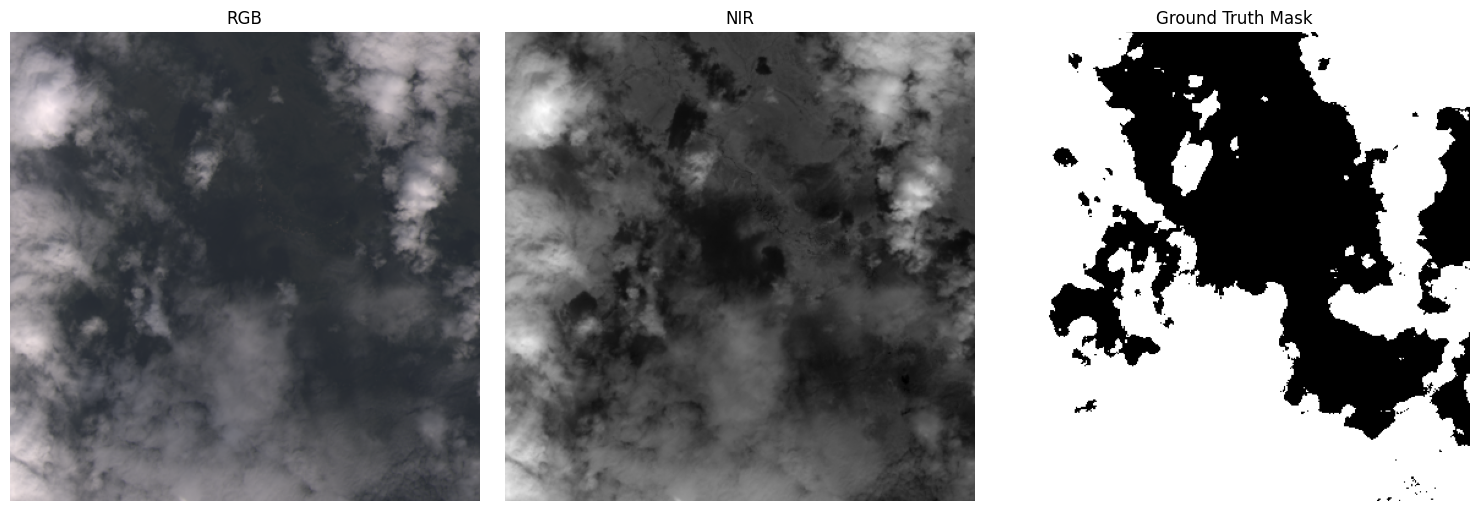

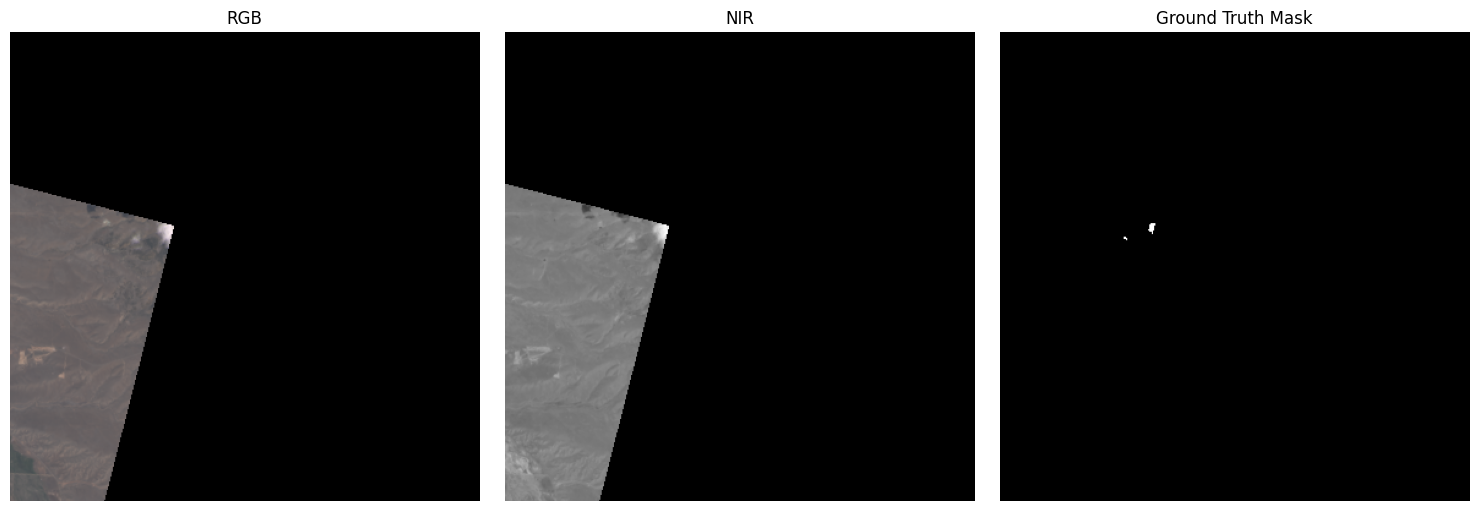

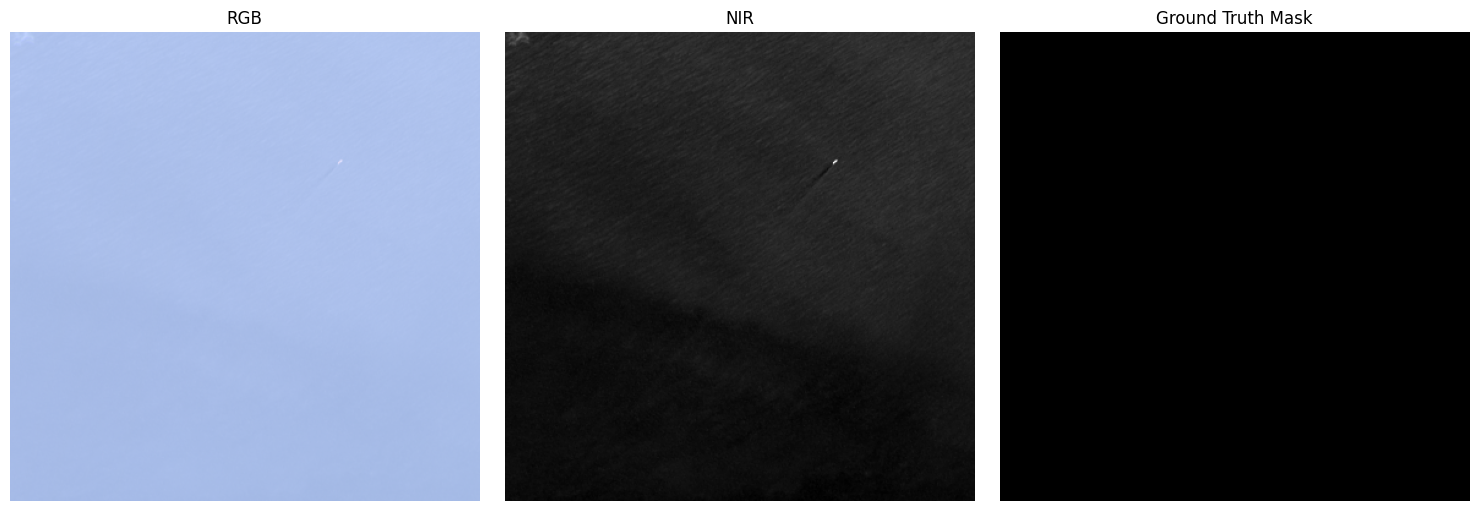

In [ ]:
def show_sample(dataset, idx):
    image, mask = dataset[idx]
    image = image.numpy()
    mask = mask.numpy().squeeze()

    rgb = np.transpose(image[:3], (1, 2, 0))
    rgb = rgb / rgb.max() if rgb.max() > 0 else rgb
    nir = image[3]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(rgb)
    axes[0].set_title('RGB')
    axes[0].axis('off')

    axes[1].imshow(nir, cmap='gray')
    axes[1].set_title('NIR')
    axes[1].axis('off')

    axes[2].imshow(mask, cmap='gray')
    axes[2].set_title('Ground Truth Mask')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

for idx in [0, 100, 500]:
    show_sample(full_dataset, idx)

In [ ]:
from torch.utils.data import DataLoader, Subset
import numpy as np

def compute_pixel_distribution_fast(dataset, sample_size=2000, batch_size=32, num_workers=4):
    n = min(sample_size, len(dataset))
    indices = np.random.choice(len(dataset), n, replace=False)
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=batch_size, num_workers=num_workers)

    cloud_pixels = 0
    total_pixels = 0
    per_patch_ratio = []

    for _, masks in loader:
        masks = masks.numpy()
        for m in masks:
            c = m.sum()
            t = m.size
            cloud_pixels += c
            total_pixels += t
            per_patch_ratio.append(c / t)

    return cloud_pixels, total_pixels, per_patch_ratio

In [ ]:
print(full_dataset.red_dir)

/content/drive/MyDrive/cloud-segmentation/data/38-cloud-extracted/train_red


In [ ]:
import os
print(os.path.exists('/content/38-cloud/train_red'))

True


In [ ]:
root_local = '/content/38-cloud'
full_dataset_local = CloudDataset(
    red_dir=os.path.join(root_local, 'train_red'),
    green_dir=os.path.join(root_local, 'train_green'),
    blue_dir=os.path.join(root_local, 'train_blue'),
    nir_dir=os.path.join(root_local, 'train_nir'),
    gt_dir=os.path.join(root_local, 'train_gt'),
)

cloud_px, total_px, ratios = compute_pixel_distribution_fast(
    full_dataset_local, sample_size=500, batch_size=16, num_workers=0
)

In [ ]:
non_cloud_px = total_px - cloud_px
print(f"Cloud pixels: {cloud_px:.0f} ({100*cloud_px/total_px:.2f}%)")
print(f"Non-cloud pixels: {non_cloud_px:.0f} ({100*non_cloud_px/total_px:.2f}%)")

Cloud pixels: 20047264 (27.19%)
Non-cloud pixels: 53680736 (72.81%)


In [ ]:
imbalance_ratio = non_cloud_px / cloud_px
print(f"Imbalance ratio (non-cloud:cloud) = {imbalance_ratio:.2f} : 1")

Imbalance ratio (non-cloud:cloud) = 2.68 : 1


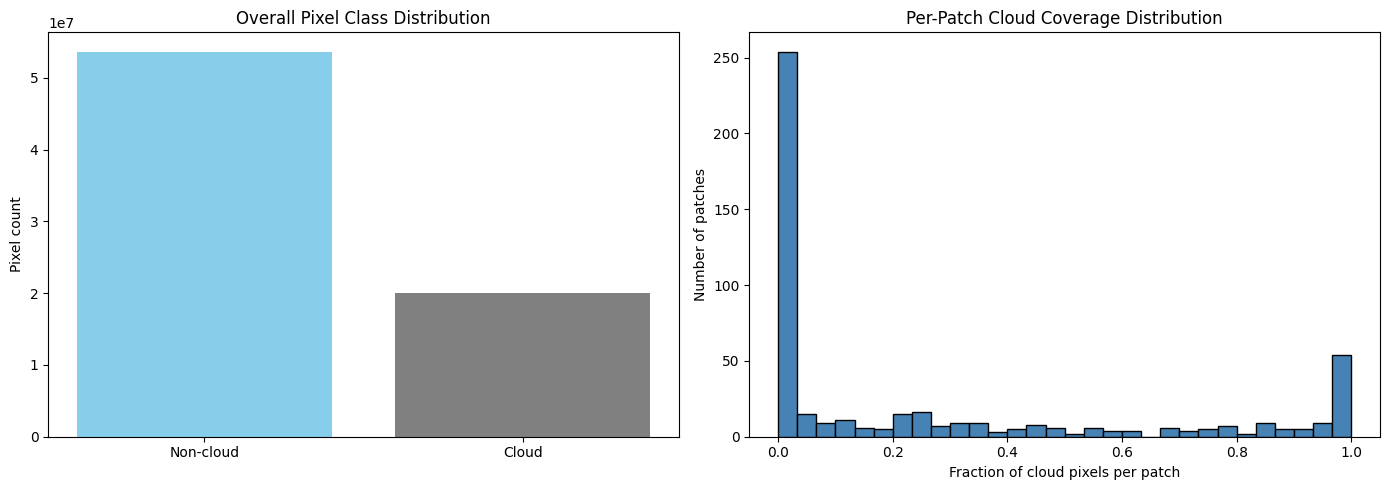

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Non-cloud', 'Cloud'], [non_cloud_px, cloud_px], color=['skyblue', 'gray'])
axes[0].set_title('Overall Pixel Class Distribution')
axes[0].set_ylabel('Pixel count')

axes[1].hist(ratios, bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Per-Patch Cloud Coverage Distribution')
axes[1].set_xlabel('Fraction of cloud pixels per patch')
axes[1].set_ylabel('Number of patches')

plt.tight_layout()
plt.show()

###Task 2 Model Architecture

In [ ]:
%%writefile /content/drive/MyDrive/cloud-segmentation/model.py
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base, base * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base * 8, base * 16)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)

        self.final = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)
        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        b = self.bottleneck(p4)

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        return torch.sigmoid(out)

Overwriting /content/drive/MyDrive/cloud-segmentation/model.py


###Task 3 Trainining Pipeline

*   Loss function (BCE/Dice loss,combine)
*   Optimizer (Adam or Adamw + A reasonable Lr schedule)
*   Metric tracked per epoch (train loss, val loss, IoU,F1)
*   Eary stopping
*   Checkpointing (weight best val IoU)







In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=4, out_channels=1).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Using device:", device)

Using device: cuda


In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = (2 * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)
        return 1 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCELoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight

    def forward(self, pred, target):
        return self.bce_weight * self.bce(pred, target) + (1 - self.bce_weight) * self.dice(pred, target)


def compute_iou(pred, target, threshold=0.5, smooth=1.0):
    pred_binary = (pred > threshold).float()
    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum() - intersection
    return (intersection + smooth) / (union + smooth)


def compute_f1(pred, target, threshold=0.5, smooth=1.0):
    pred_binary = (pred > threshold).float()
    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return (2 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


def validate_one_epoch(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_f1 = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            running_loss += loss.item() * images.size(0)
            running_iou += compute_iou(outputs, masks).item() * images.size(0)
            running_f1 += compute_f1(outputs, masks).item() * images.size(0)
    n = len(loader.dataset)
    return running_loss / n, running_iou / n, running_f1 / n


def train_model(model, train_loader, val_loader, optimizer, scheduler, loss_fn,
                 device, num_epochs=50, patience=5, checkpoint_path='best_model.pth'):
    best_val_loss = float('inf')
    best_val_iou = 0.0
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_f1': []}

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_iou, val_f1 = validate_one_epoch(model, val_loader, loss_fn, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)
        history['val_f1'].append(val_f1)

        print(f"Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | val_iou={val_iou:.4f} | val_f1={val_f1:.4f}")

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), checkpoint_path)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return history

In [ ]:
spec2 = importlib.util.spec_from_file_location("dataset", "/content/drive/MyDrive/cloud-segmentation/dataset.py")
dataset_module = importlib.util.module_from_spec(spec2)
spec2.loader.exec_module(dataset_module)
get_train_val_loaders = dataset_module.get_train_val_loaders

root = '/content/38-cloud'
train_loader, val_loader = get_train_val_loaders(root, batch_size=32)

loss_fn = BCEDiceLoss()
history = train_model(
    model, train_loader, val_loader, optimizer, scheduler, loss_fn,
    device, num_epochs=3, patience=5,
    checkpoint_path='/content/drive/MyDrive/cloud-segmentation/outputs/best_model.pth'
)

สร้างmodel optimizer ใหม่

In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/cloud-segmentation')

import importlib.util
spec = importlib.util.spec_from_file_location("model", "/content/drive/MyDrive/cloud-segmentation/model.py")
model_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model_module)
UNet = model_module.UNet

In [ ]:
model = UNet(in_channels=4, out_channels=1).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Model reset. Using device:", device)

Model reset. Using device: cuda


In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = (2 * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)
        return 1 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCELoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight

    def forward(self, pred, target):
        return self.bce_weight * self.bce(pred, target) + (1 - self.bce_weight) * self.dice(pred, target)


def compute_iou(pred, target, threshold=0.5, smooth=1.0):
    pred_binary = (pred > threshold).float()
    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum() - intersection
    return (intersection + smooth) / (union + smooth)


def compute_f1(pred, target, threshold=0.5, smooth=1.0):
    pred_binary = (pred > threshold).float()
    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return (2 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


def validate_one_epoch(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_f1 = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            running_loss += loss.item() * images.size(0)
            running_iou += compute_iou(outputs, masks).item() * images.size(0)
            running_f1 += compute_f1(outputs, masks).item() * images.size(0)
    n = len(loader.dataset)
    return running_loss / n, running_iou / n, running_f1 / n


def train_model(model, train_loader, val_loader, optimizer, scheduler, loss_fn,
                 device, num_epochs=50, patience=5, checkpoint_path='best_model.pth'):
    best_val_loss = float('inf')
    best_val_iou = 0.0
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_f1': []}

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_iou, val_f1 = validate_one_epoch(model, val_loader, loss_fn, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)
        history['val_f1'].append(val_f1)

        print(f"Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | val_iou={val_iou:.4f} | val_f1={val_f1:.4f}")

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), checkpoint_path)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return history

print("Defined successfully")

Defined successfully


In [ ]:
import importlib.util
spec2 = importlib.util.spec_from_file_location("dataset", "/content/drive/MyDrive/cloud-segmentation/dataset.py")
dataset_module = importlib.util.module_from_spec(spec2)
spec2.loader.exec_module(dataset_module)
get_train_val_loaders = dataset_module.get_train_val_loaders

root = '/content/38-cloud'
train_loader, val_loader = get_train_val_loaders(root, batch_size=32)
loss_fn = BCEDiceLoss()

history = train_model(
    model, train_loader, val_loader, optimizer, scheduler, loss_fn,
    device, num_epochs=50, patience=5,
    checkpoint_path='/content/drive/MyDrive/cloud-segmentation/outputs/best_model.pth'
)

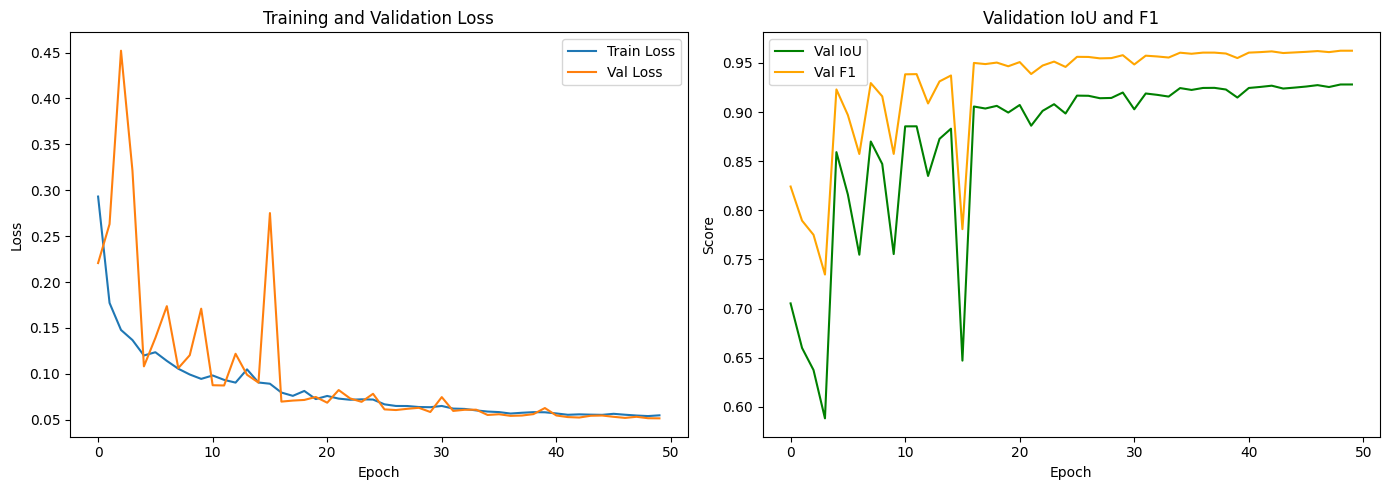

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

axes[1].plot(history['val_iou'], label='Val IoU', color='green')
axes[1].plot(history['val_f1'], label='Val F1', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation IoU and F1')
axes[1].legend()

plt.tight_layout()

import os
os.makedirs('/content/drive/MyDrive/cloud-segmentation/outputs', exist_ok=True)
plt.savefig('/content/drive/MyDrive/cloud-segmentation/outputs/training_curves.png', dpi=150)
plt.show()

In [ ]:
%%writefile /content/drive/MyDrive/cloud-segmentation/train.py
import argparse
import os

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from dataset import get_train_val_loaders
from model import UNet


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = (2 * intersection + self.smooth) / (
            pred_flat.sum() + target_flat.sum() + self.smooth
        )
        return 1 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCELoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight

    def forward(self, pred, target):
        return self.bce_weight * self.bce(pred, target) + (
            1 - self.bce_weight
        ) * self.dice(pred, target)


def compute_iou(pred, target, threshold=0.5, smooth=1.0):
    pred_binary = (pred > threshold).float()
    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum() - intersection
    return (intersection + smooth) / (union + smooth)


def compute_f1(pred, target, threshold=0.5, smooth=1.0):
    pred_binary = (pred > threshold).float()
    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return (2 * intersection + smooth) / (
        pred_flat.sum() + target_flat.sum() + smooth
    )


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


def validate_one_epoch(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_f1 = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            running_loss += loss.item() * images.size(0)
            running_iou += compute_iou(outputs, masks).item() * images.size(0)
            running_f1 += compute_f1(outputs, masks).item() * images.size(0)
    n = len(loader.dataset)
    return running_loss / n, running_iou / n, running_f1 / n


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    loss_fn,
    device,
    num_epochs=50,
    patience=5,
    checkpoint_path="outputs/best_model.pth",
):
    best_val_loss = float("inf")
    best_val_iou = 0.0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_iou": [], "val_f1": []}

    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_iou, val_f1 = validate_one_epoch(model, val_loader, loss_fn, device)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch {epoch + 1}/{num_epochs} | train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | val_iou={val_iou:.4f} | val_f1={val_f1:.4f}"
        )

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), checkpoint_path)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

    return history


def plot_training_curves(history, save_path="outputs/training_curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].legend()

    axes[1].plot(history["val_iou"], label="Val IoU", color="green")
    axes[1].plot(history["val_f1"], label="Val F1", color="orange")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_title("Validation IoU and F1")
    axes[1].legend()

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150)
    plt.close(fig)
    print(f"Saved training curves to {save_path}")


def main():
    parser = argparse.ArgumentParser(description="Train the cloud segmentation U-Net.")
    parser.add_argument("--data_root", type=str, default="./38-cloud")
    parser.add_argument("--epochs", type=int, default=50)
    parser.add_argument("--batch_size", type=int, default=32)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--patience", type=int, default=5)
    parser.add_argument("--val_split", type=float, default=0.2)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--checkpoint_path", type=str, default="outputs/best_model.pth")
    parser.add_argument("--curves_path", type=str, default="outputs/training_curves.png")
    args = parser.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model = UNet(in_channels=4, out_channels=1).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=args.lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    train_loader, val_loader = get_train_val_loaders(
        args.data_root,
        batch_size=args.batch_size,
        val_split=args.val_split,
        seed=args.seed,
    )
    print("Train patches:", len(train_loader.dataset))
    print("Val patches:", len(val_loader.dataset))

    loss_fn = BCEDiceLoss()

    history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        scheduler,
        loss_fn,
        device,
        num_epochs=args.epochs,
        patience=args.patience,
        checkpoint_path=args.checkpoint_path,
    )

    plot_training_curves(history, save_path=args.curves_path)


if __name__ == "__main__":
    main()

Overwriting /content/drive/MyDrive/cloud-segmentation/train.py


###Task 4 Evaluation and Testing

*   Evaluate ตัว train on the held-out **test set**
*   Metric
     
     *Pixel accuracy %  
     
     *IoU (Jaccard) (cloud class)
     
     *F1/Dice score
     
     *Precision
     
     *Recall
* 5 qualitative visualization
* (RGB/Ground Truth/Prediction Mask)
* outputs/predictions/.







In [ ]:
def compute_metrics(pred, target, threshold=0.5, smooth=1e-7):
    pred_binary = (pred > threshold).float()
    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)

    TP = (pred_flat * target_flat).sum()
    TN = ((1 - pred_flat) * (1 - target_flat)).sum()
    FP = (pred_flat * (1 - target_flat)).sum()
    FN = ((1 - pred_flat) * target_flat).sum()

    accuracy = (TP + TN) / (TP + TN + FP + FN + smooth)
    precision = TP / (TP + FP + smooth)
    recall = TP / (TP + FN + smooth)
    iou = TP / (TP + FP + FN + smooth)
    f1 = 2 * TP / (2 * TP + FP + FN + smooth)

    return {
        "accuracy": accuracy.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "iou": iou.item(),
        "f1": f1.item(),
    }

In [ ]:
pred_test = torch.rand(1, 1, 4, 4)
target_test = torch.randint(0, 2, (1, 1, 4, 4)).float()

metrics = compute_metrics(pred_test, target_test)
print(metrics)

{'accuracy': 0.5, 'precision': 0.5714285969734192, 'recall': 0.4444444477558136, 'iou': 0.3333333432674408, 'f1': 0.5}


In [ ]:
def evaluate_model(model, loader, device):
    model.eval()
    all_metrics = {"accuracy": [], "precision": [], "recall": [], "iou": [], "f1": []}

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            batch_metrics = compute_metrics(outputs, masks)
            for k, v in batch_metrics.items():
                all_metrics[k].append(v)

    avg_metrics = {k: sum(v) / len(v) for k, v in all_metrics.items()}
    return avg_metrics

In [ ]:
model.load_state_dict(torch.load('/content/drive/MyDrive/cloud-segmentation/outputs/best_model.pth'))
model.eval()

final_metrics = evaluate_model(model, val_loader, device)
print(final_metrics)

{'accuracy': 0.9786720770709919, 'precision': 0.9640635915522305, 'recall': 0.961303784037536, 'iou': 0.9282991931123553, 'f1': 0.9625481344618887}


In [ ]:
import json

os.makedirs('/content/drive/MyDrive/cloud-segmentation/outputs', exist_ok=True)
metrics_path = '/content/drive/MyDrive/cloud-segmentation/outputs/metrics.json'

with open(metrics_path, 'w') as f:
    json.dump(final_metrics, f, indent=2)

print(f"Saved metrics to {metrics_path}")

Saved metrics to /content/drive/MyDrive/cloud-segmentation/outputs/metrics.json


กรองภาพ

In [ ]:
def get_top_k_iou_indices(model, dataset, device, k=5, min_cloud_ratio=0.05, max_cloud_ratio=0.95):
    model.eval()
    iou_scores = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            image, mask = dataset[idx]

            cloud_ratio = mask.sum().item() / mask.numel()
            if cloud_ratio < min_cloud_ratio or cloud_ratio > max_cloud_ratio:
                continue

            image_batch = image.unsqueeze(0).to(device)
            mask_batch = mask.unsqueeze(0).to(device)
            pred = model(image_batch)
            iou = compute_iou(pred, mask_batch).item()
            iou_scores.append((idx, iou))

    iou_scores.sort(key=lambda x: x[1], reverse=True)
    top_k_indices = [idx for idx, score in iou_scores[:k]]
    top_k_scores = [score for idx, score in iou_scores[:k]]

    return top_k_indices, top_k_scores


top_indices, top_scores = get_top_k_iou_indices(model, val_loader.dataset, device, k=5)
print("Top 5 IoU scores (excluding extreme cases):", top_scores)
print("Indices:", top_indices)

Top 5 IoU scores (excluding extreme cases): [1.0, 1.0, 1.0, 1.0, 1.0]
Indices: [71, 206, 235, 308, 808]


In [ ]:
for idx in top_indices:
    image, mask = val_loader.dataset[idx]
    cloud_pixels = mask.sum().item()
    total_pixels = mask.numel()
    print(f"idx={idx}, cloud_pixels={cloud_pixels}, ratio={cloud_pixels/total_pixels:.4f}")

In [ ]:
def save_qualitative_predictions(model, dataset, indices, scores, device, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()

    for i, idx in enumerate(indices):
        try:
            image, mask = dataset[idx]
            with torch.no_grad():
                pred = model(image.unsqueeze(0).to(device))
                pred = (pred.squeeze().cpu().numpy() > 0.5).astype(np.float32)

            rgb = np.transpose(image[:3].numpy(), (1, 2, 0))
            rgb = rgb / rgb.max() if rgb.max() > 0 else rgb
            gt = mask.squeeze().numpy()

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(rgb)
            axes[0].set_title("RGB")
            axes[0].axis("off")

            axes[1].imshow(gt, cmap="gray")
            axes[1].set_title("Ground Truth")
            axes[1].axis("off")

            axes[2].imshow(pred, cmap="gray")
            axes[2].set_title(f"Prediction (IoU={scores[i]:.3f})")
            axes[2].axis("off")

            plt.tight_layout(pad=2.0)
            plt.savefig(os.path.join(save_dir, f"prediction_{i+1}.png"), dpi=150, bbox_inches='tight')
            plt.close(fig)
            print(f"Saved patch {i+1} (idx={idx}, IoU={scores[i]:.3f})")
        except Exception as e:
            print(f"Error at index {idx}: {e}")


save_dir = '/content/drive/MyDrive/cloud-segmentation/outputs/predictions'
save_qualitative_predictions(model, val_loader.dataset, top_indices, top_scores, device, save_dir)

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


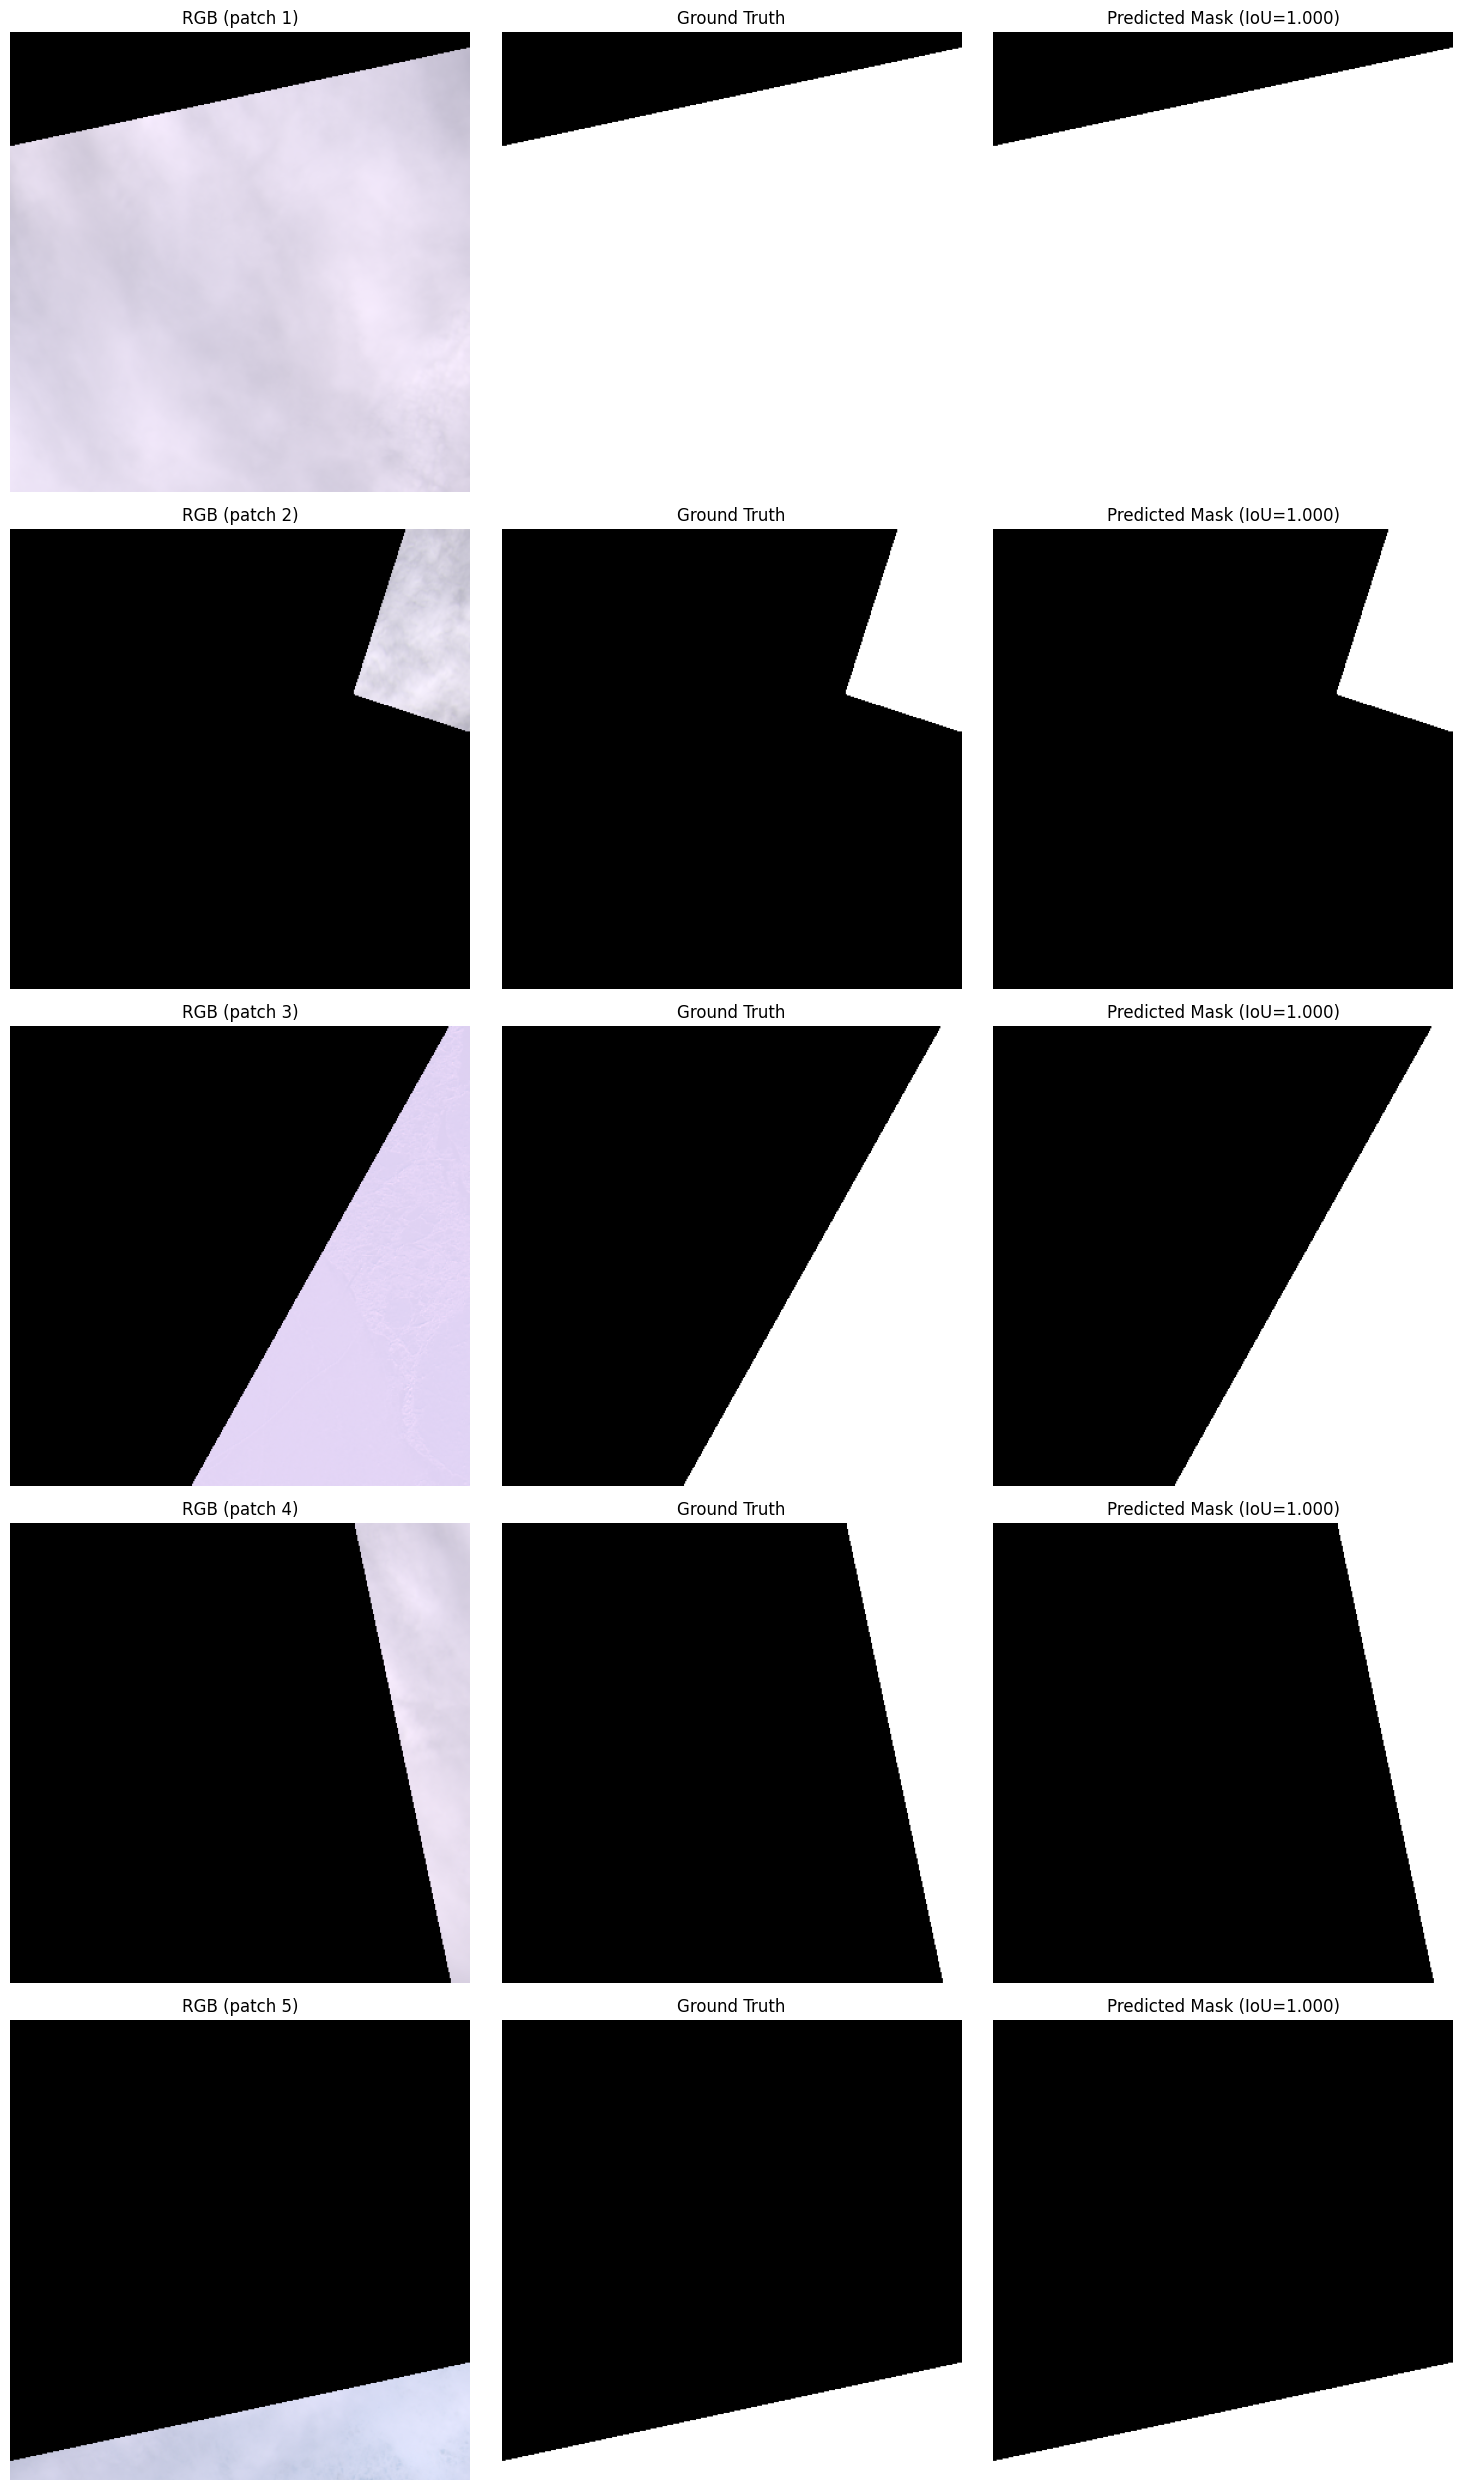

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(5, 3, figsize=(15, 25))

for i, idx in enumerate(top_indices):
    image, mask = val_loader.dataset[idx]
    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device))
        pred = (pred.squeeze().cpu().numpy() > 0.5).astype(np.float32)

    rgb = np.transpose(image[:3].numpy(), (1, 2, 0))
    rgb = rgb / rgb.max() if rgb.max() > 0 else rgb
    gt = mask.squeeze().numpy()

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"RGB (patch {i+1})")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gt, cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred, cmap="gray")
    axes[i, 2].set_title(f"Predicted Mask (IoU={top_scores[i]:.3f})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cloud-segmentation/outputs/predictions/qualitative_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
%%writefile /content/drive/MyDrive/cloud-segmentation/evaluate.py
import argparse
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

from dataset import get_train_val_loaders
from model import UNet

# Metrics

def compute_iou(pred, target, threshold=0.5, smooth=1.0):
    pred_binary = (pred > threshold).float()
    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum() - intersection
    return (intersection + smooth) / (union + smooth)


def compute_metrics(pred, target, threshold=0.5, smooth=1e-7):
    pred_binary = (pred > threshold).float()
    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)

    TP = (pred_flat * target_flat).sum()
    TN = ((1 - pred_flat) * (1 - target_flat)).sum()
    FP = (pred_flat * (1 - target_flat)).sum()
    FN = ((1 - pred_flat) * target_flat).sum()

    accuracy = (TP + TN) / (TP + TN + FP + FN + smooth)
    precision = TP / (TP + FP + smooth)
    recall = TP / (TP + FN + smooth)
    iou = TP / (TP + FP + FN + smooth)
    f1 = 2 * TP / (2 * TP + FP + FN + smooth)

    return {
        "accuracy": accuracy.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "iou": iou.item(),
        "f1": f1.item(),
    }


def evaluate_model(model, loader, device):
    model.eval()
    all_metrics = {"accuracy": [], "precision": [], "recall": [], "iou": [], "f1": []}

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            batch_metrics = compute_metrics(outputs, masks)
            for k, v in batch_metrics.items():
                all_metrics[k].append(v)

    avg_metrics = {k: sum(v) / len(v) for k, v in all_metrics.items()}
    return avg_metrics

# Qualitative visualization

def get_top_k_iou_indices(model, dataset, device, k=5, min_cloud_ratio=0.05, max_cloud_ratio=0.95):
    """Rank patches by IoU, restricted to patches that actually contain a
    mix of cloud/non-cloud pixels (excludes trivial all-clear or all-cloud
    patches, which otherwise dominate a naive top-k by IoU)."""
    model.eval()
    iou_scores = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            image, mask = dataset[idx]

            cloud_ratio = mask.sum().item() / mask.numel()
            if cloud_ratio < min_cloud_ratio or cloud_ratio > max_cloud_ratio:
                continue

            image_batch = image.unsqueeze(0).to(device)
            mask_batch = mask.unsqueeze(0).to(device)
            pred = model(image_batch)
            iou = compute_iou(pred, mask_batch).item()
            iou_scores.append((idx, iou))

    iou_scores.sort(key=lambda x: x[1], reverse=True)
    top_k_indices = [idx for idx, score in iou_scores[:k]]
    top_k_scores = [score for idx, score in iou_scores[:k]]

    return top_k_indices, top_k_scores


def save_qualitative_predictions(model, dataset, indices, scores, device, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()

    for i, idx in enumerate(indices):
        try:
            image, mask = dataset[idx]
            with torch.no_grad():
                pred = model(image.unsqueeze(0).to(device))
                pred = (pred.squeeze().cpu().numpy() > 0.5).astype(np.float32)

            rgb = np.transpose(image[:3].numpy(), (1, 2, 0))
            rgb = rgb / rgb.max() if rgb.max() > 0 else rgb
            gt = mask.squeeze().numpy()

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(rgb)
            axes[0].set_title("RGB")
            axes[0].axis("off")

            axes[1].imshow(gt, cmap="gray")
            axes[1].set_title("Ground Truth")
            axes[1].axis("off")

            axes[2].imshow(pred, cmap="gray")
            axes[2].set_title(f"Prediction (IoU={scores[i]:.3f})")
            axes[2].axis("off")

            plt.tight_layout(pad=2.0)
            plt.savefig(
                os.path.join(save_dir, f"prediction_{i + 1}.png"),
                dpi=150,
                bbox_inches="tight",
            )
            plt.close(fig)
            print(f"Saved patch {i + 1} (idx={idx}, IoU={scores[i]:.3f})")
        except Exception as e:
            print(f"Error at index {idx}: {e}")

    print(f"Saved {len(indices)} qualitative predictions to {save_dir}")


#Entry point

def main():
    parser = argparse.ArgumentParser(description="Evaluate the cloud segmentation U-Net.")
    parser.add_argument("--data_root", type=str, default="./38-cloud")
    parser.add_argument("--checkpoint", type=str, default="outputs/best_model.pth")
    parser.add_argument("--batch_size", type=int, default=32)
    parser.add_argument("--val_split", type=float, default=0.2)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--num_qualitative", type=int, default=5)
    parser.add_argument("--metrics_path", type=str, default="outputs/metrics.json")
    parser.add_argument("--predictions_dir", type=str, default="outputs/predictions")
    args = parser.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model = UNet(in_channels=4, out_channels=1).to(device)
    model.load_state_dict(torch.load(args.checkpoint, map_location=device))
    model.eval()

    _, val_loader = get_train_val_loaders(
        args.data_root,
        batch_size=args.batch_size,
        val_split=args.val_split,
        seed=args.seed,
    )
    print("Evaluation patches (validation split):", len(val_loader.dataset))

    final_metrics = evaluate_model(model, val_loader, device)
    print("Metrics:", final_metrics)

    os.makedirs(os.path.dirname(args.metrics_path), exist_ok=True)
    with open(args.metrics_path, "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"Saved metrics to {args.metrics_path}")

    top_indices, top_scores = get_top_k_iou_indices(
        model, val_loader.dataset, device, k=args.num_qualitative
    )
    save_qualitative_predictions(
        model, val_loader.dataset, top_indices, top_scores, device, args.predictions_dir
    )


if __name__ == "__main__":
    main()

Writing /content/drive/MyDrive/cloud-segmentation/evaluate.py


Bonus

In [ ]:
%%writefile /content/drive/MyDrive/cloud-segmentation/dataset.py
import os
import random

import numpy as np
import pandas as pd
import rasterio
import torch
from torch.utils.data import Dataset, DataLoader, Subset


def augment(image, mask):
    """Random flips/rotations applied to all 4 bands + mask together;
    color jitter (brightness) applied to RGB channels only, leaving
    NIR untouched as required."""
    # Random horizontal flip
    if random.random() > 0.5:
        image = torch.flip(image, dims=[2])
        mask = torch.flip(mask, dims=[2])

    # Random vertical flip
    if random.random() > 0.5:
        image = torch.flip(image, dims=[1])
        mask = torch.flip(mask, dims=[1])

    # Random 90 rotation
    if random.random() > 0.5:
        k = random.choice([1, 2, 3])
        image = torch.rot90(image, k, dims=[1, 2])
        mask = torch.rot90(mask, k, dims=[1, 2])

    # Color jitter (brightness) (RGB)
    if random.random() > 0.5:
        rgb = image[:3]
        nir = image[3:4]
        brightness_factor = random.uniform(0.8, 1.2)
        rgb = torch.clamp(rgb * brightness_factor, 0, 1)
        image = torch.cat([rgb, nir], dim=0)

    return image, mask


class CloudDataset(Dataset):
    def __init__(self, red_dir, green_dir, blue_dir, nir_dir, gt_dir=None,
                 file_list=None, augment_data=False):
        self.red_dir = red_dir
        self.green_dir = green_dir
        self.blue_dir = blue_dir
        self.nir_dir = nir_dir
        self.gt_dir = gt_dir
        self.filenames = file_list if file_list is not None else sorted(os.listdir(red_dir))
        self.augment_data = augment_data

    def __len__(self):
        return len(self.filenames)

    def _band_path(self, band_dir, band_name, red_filename):
        suffix = red_filename.split('_', 1)[1]
        return os.path.join(band_dir, f'{band_name}_{suffix}')

    def _read_band(self, path):
        with rasterio.open(path) as src:
            return src.read(1).astype(np.float32)

    def __getitem__(self, idx):
        red_filename = self.filenames[idx]
        red = self._read_band(os.path.join(self.red_dir, red_filename))
        green = self._read_band(self._band_path(self.green_dir, 'green', red_filename))
        blue = self._read_band(self._band_path(self.blue_dir, 'blue', red_filename))
        nir = self._read_band(self._band_path(self.nir_dir, 'nir', red_filename))

        image = np.stack([red, green, blue, nir], axis=0) / 65535.0
        image = torch.from_numpy(image).float()

        if self.gt_dir is not None:
            mask = self._read_band(self._band_path(self.gt_dir, 'gt', red_filename))
            mask = (mask > 0).astype(np.float32)
            mask = torch.from_numpy(mask).unsqueeze(0).float()

            if self.augment_data:
                image, mask = augment(image, mask)

            return image, mask

        return image, red_filename


def _load_filenames_from_csv(csv_path):
    df = pd.read_csv(csv_path)
    return [f'red_{name}.TIF' for name in df['name']]


def get_train_val_loaders(root_dir, batch_size=8, val_split=0.2, seed=42,
                           num_workers=2, csv_path=None, use_augmentation=False):
    red_dir = os.path.join(root_dir, 'train_red')
    green_dir = os.path.join(root_dir, 'train_green')
    blue_dir = os.path.join(root_dir, 'train_blue')
    nir_dir = os.path.join(root_dir, 'train_nir')
    gt_dir = os.path.join(root_dir, 'train_gt')

    if csv_path is None:
        csv_path = os.path.join(root_dir, 'training_patches_38-Cloud.csv')
    file_list = _load_filenames_from_csv(csv_path)

    dataset_no_aug = CloudDataset(red_dir, green_dir, blue_dir, nir_dir, gt_dir,
                                   file_list=file_list, augment_data=False)
    dataset_aug = CloudDataset(red_dir, green_dir, blue_dir, nir_dir, gt_dir,
                                file_list=file_list, augment_data=use_augmentation)

    val_size = int(len(dataset_no_aug) * val_split)
    train_size = len(dataset_no_aug) - val_size

    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset_no_aug), generator=generator).tolist()
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_dataset = Subset(dataset_aug, train_indices)
    val_dataset = Subset(dataset_no_aug, val_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return train_loader, val_loader


def get_test_loader(root_dir, batch_size=8, num_workers=2, csv_path=None):
    red_dir = os.path.join(root_dir, 'test_red')
    green_dir = os.path.join(root_dir, 'test_green')
    blue_dir = os.path.join(root_dir, 'test_blue')
    nir_dir = os.path.join(root_dir, 'test_nir')

    if csv_path is None:
        csv_path = os.path.join(root_dir, 'test_patches_38-Cloud.csv')
    file_list = _load_filenames_from_csv(csv_path)

    test_dataset = CloudDataset(red_dir, green_dir, blue_dir, nir_dir, gt_dir=None, file_list=file_list)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

Overwriting /content/drive/MyDrive/cloud-segmentation/dataset.py


In [ ]:
import importlib.util
spec = importlib.util.spec_from_file_location("dataset", "/content/drive/MyDrive/cloud-segmentation/dataset.py")
dataset_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dataset_module)
get_train_val_loaders = dataset_module.get_train_val_loaders

train_loader_aug, val_loader_check = get_train_val_loaders(
    '/content/38-cloud', batch_size=8, use_augmentation=True
)
print("Train:", len(train_loader_aug.dataset), "Val:", len(val_loader_check.dataset))

images, masks = next(iter(train_loader_aug))
print("Shape:", images.shape, masks.shape)

**Bonus 1** **BCE+Dice + Augmentation**

In [ ]:
model_aug = UNet(in_channels=4, out_channels=1).to(device)
optimizer_aug = optim.AdamW(model_aug.parameters(), lr=1e-3)
scheduler_aug = optim.lr_scheduler.ReduceLROnPlateau(optimizer_aug, mode='min', factor=0.5, patience=3)

train_loader_aug, val_loader_aug = get_train_val_loaders(
    '/content/38-cloud', batch_size=32, use_augmentation=True
)
print("Train:", len(train_loader_aug.dataset), "Val:", len(val_loader_aug.dataset))

loss_fn = BCEDiceLoss()

history_aug = train_model(
    model_aug, train_loader_aug, val_loader_aug, optimizer_aug, scheduler_aug, loss_fn,
    device, num_epochs=50, patience=5,
    checkpoint_path='/content/drive/MyDrive/cloud-segmentation/outputs/best_model_augmented.pth'
)

In [ ]:
import json

with open('/content/drive/MyDrive/cloud-segmentation/outputs/history_augmented.json', 'w') as f:
    json.dump(history_aug, f, indent=2)

print("Saved augmented history")

Saved augmented history


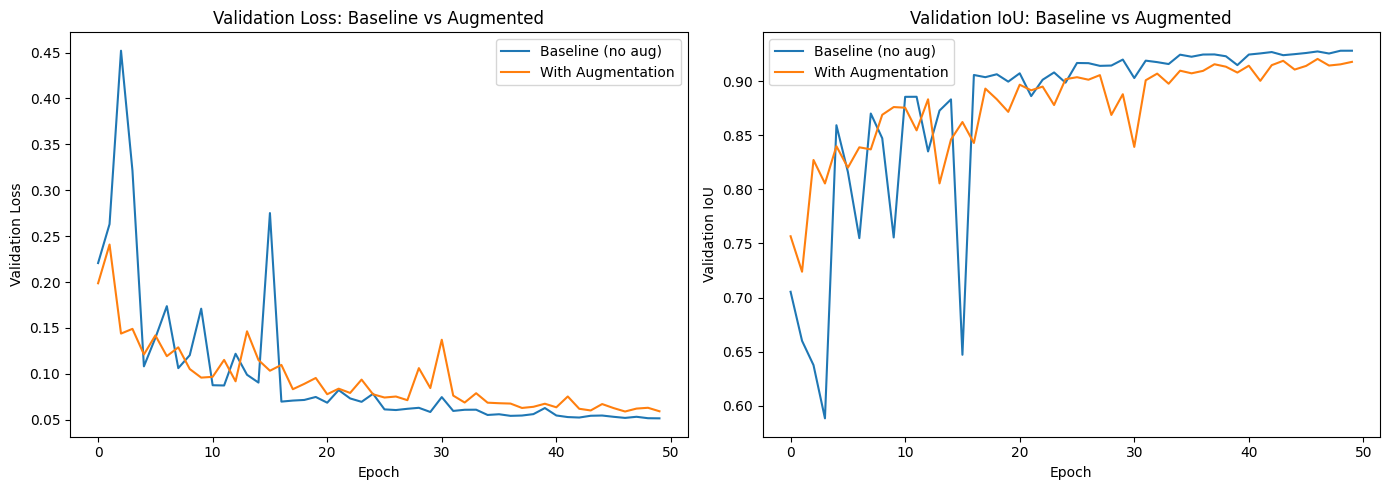

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['val_loss'], label='Baseline (no aug)')
axes[0].plot(history_aug['val_loss'], label='With Augmentation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss: Baseline vs Augmented')
axes[0].legend()

axes[1].plot(history['val_iou'], label='Baseline (no aug)')
axes[1].plot(history_aug['val_iou'], label='With Augmentation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation IoU')
axes[1].set_title('Validation IoU: Baseline vs Augmented')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cloud-segmentation/outputs/comparison_augmentation.png', dpi=150)
plt.show()

In [ ]:
model_bce = UNet(in_channels=4, out_channels=1).to(device)
optimizer_bce = optim.AdamW(model_bce.parameters(), lr=1e-3)
scheduler_bce = optim.lr_scheduler.ReduceLROnPlateau(optimizer_bce, mode='min', factor=0.5, patience=3)

train_loader_plain, val_loader_plain = get_train_val_loaders(
    '/content/38-cloud', batch_size=32, use_augmentation=False
)

plain_bce_loss = nn.BCELoss()

history_bce = train_model(
    model_bce, train_loader_plain, val_loader_plain, optimizer_bce, scheduler_bce, plain_bce_loss,
    device, num_epochs=50, patience=5,
    checkpoint_path='/content/drive/MyDrive/cloud-segmentation/outputs/best_model_bce_only.pth'
)

In [ ]:
import json

with open('/content/drive/MyDrive/cloud-segmentation/outputs/history_bce_only.json', 'w') as f:
    json.dump(history_bce, f, indent=2)

**Bonus 2** **Loss Function Comparison**

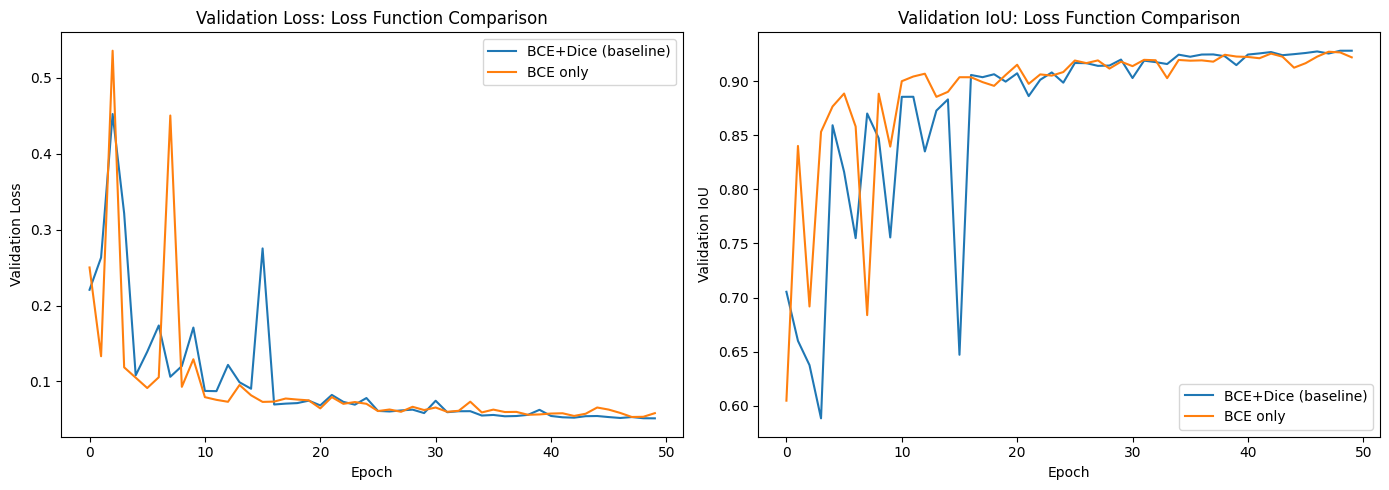

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['val_loss'], label='BCE+Dice (baseline)')
axes[0].plot(history_bce['val_loss'], label='BCE only')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss: Loss Function Comparison')
axes[0].legend()

axes[1].plot(history['val_iou'], label='BCE+Dice (baseline)')
axes[1].plot(history_bce['val_iou'], label='BCE only')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation IoU')
axes[1].set_title('Validation IoU: Loss Function Comparison')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cloud-segmentation/outputs/comparison_loss_function.png', dpi=150)
plt.show()